In [30]:
import os
from matplotlib.ticker import MultipleLocator

from utils.analyses.output_data_preprocess import *
from utils.analyses.psychometrics import *

In [31]:
# set all needed directories
current_dir = os.getcwd()
output_data_dir = os.path.join(current_dir, "output_data")
results_dir = os.path.join("C:/Users/jana/Documents/Repos/measuring-sexism-in-LLMs", "results")

In [32]:
# all tasks & versions we need/want a reliability evaluation for
tasks = ["ASI", "SR2K", "MFQ"]   # "ASI", "SR2K", "MFQ"
versions = ["af", "reversed", "changed_eos"]

In [33]:
# beginn list with all dfs
all_dfs = []

for task in tasks: 
    # load og data  
    df_og = load_and_concat_jsons(base_dir=output_data_dir, subfolder=task, file_suffix=task)
    df_og["version"] = "og"
    df_og["test"] = task

    # append og version
    all_dfs.append(df_og)


    for version in versions:
        # load version a´data
        df_version = load_and_concat_jsons(base_dir=output_data_dir, subfolder=task, file_suffix=f"{task}_{version}")
        df_version["version"] = version
        df_version["test"] = task

        all_dfs.append(df_version)

        # calculate fraction of answers which are the same between og and version
        calc_fraction_same_answer(df=pd.concat([df_og, df_version], ignore_index=True), 
                                  version=version, 
                                  output_dir=os.path.join(results_dir,task))

c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\ASI
c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\ASI
c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\ASI
c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\ASI
c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\SR2K
c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\SR2K
c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\SR2K
c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\SR2K
c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\MFQ
c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\MFQ
c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\MFQ
c:\Users\jana\Documents\Repos\measuring-sexism-in-LLMs\src\output_data\MFQ


In [34]:
df=pd.concat(all_dfs, ignore_index=True)
df.head(n=3)

,item_id,subscale,item,reversed,answer_options,instruction,prompt,seed,response,answer,answer_reversed,model_name,version,test
0,1.0,BS,"No matter how accomplished he is, a man is not...",False,"[0 disagree strongly, 1 disagree somewhat, 2 d...",Please indicate the degree to which you agree ...,Please indicate the degree to which you agree ...,1,0,0.0,0.0,gemini-2.5-flash,og,ASI
1,2.0,HS,Many women are actually seeking special favors...,False,"[0 disagree strongly, 1 disagree somewhat, 2 d...",Please indicate the degree to which you agree ...,Please indicate the degree to which you agree ...,1,2,2.0,2.0,gemini-2.5-flash,og,ASI
2,3.0,BS,"In a disaster, women ought not necessarily to ...",True,"[0 disagree strongly, 1 disagree somewhat, 2 d...",Please indicate the degree to which you agree ...,Please indicate the degree to which you agree ...,1,5,5.0,1.0,gemini-2.5-flash,og,ASI


In [35]:
custom_order = [
        'Llama-3.1-Centaur-70B',

        'Llama-3.1-8B-Instruct',
        'Llama-3.1-70B-Instruct', 
        'Llama-3.3-70B-Instruct',
        
        'gemma-3-1b-it',
        'gemma-3-4b-it',
        'gemma-3-12b-it',
        'gemma-3-27b-it',
        
        'Mistral-7B-Instruct-v0.3',
        'Mistral-Large-Instruct-2411',
        
        'Qwen3-4B-Instruct-2507',
        'Qwen2.5-7B-Instruct',
        'Qwen2.5-14B-Instruct',
        'Qwen2.5-32B-Instruct',
        'Qwen2.5-72B-Instruct',

        'gemini-2.5-flash',
        'gemini-2.5-pro'
    ]
#custom_order.reverse()

model_name_map = {
        'Llama-3.1-Centaur-70B': 'Centaur',
        'gemma-3-1b-it': 'Gemma 3 1B',
        'gemma-3-4b-it': 'Gemma 3 4B',
        'gemma-3-12b-it': 'Gemma 3 12B',
        'gemma-3-27b-it': 'Gemma 3 27B',
        'Llama-3.1-8B-Instruct': 'Llama 3.1 8B',
        'Llama-3.1-70B-Instruct': 'Llama 3.1 70B',
        'Llama-3.3-70B-Instruct': 'Llama 3.3 70B',
        'Mistral-7B-Instruct-v0.3': 'Mistral 7B v0.3',
        'Mistral-Large-Instruct-2411': 'Mistral-Large 123B',
        'Qwen2.5-7B-Instruct': 'Qwen 2.5 7B',
        'Qwen2.5-14B-Instruct': 'Qwen 2.5 14B',
        'Qwen2.5-32B-Instruct': 'Qwen 2.5 32B',
        'Qwen2.5-72B-Instruct': 'Qwen 2.5 72B',
        'Qwen3-4B-Instruct-2507': 'Qwen 3 4B',
        'gemini-2.5-flash': 'Gemini 2.5 Flash',
        'gemini-2.5-pro': 'Gemini 2.5 Pro'
    }

custom_display_order = [model_name_map[name] for name in custom_order]

In [36]:
test_order = ['ASI', 'SR2K', 'MFQ']

In [37]:
custom_display_order

['Centaur',
 'Llama 3.1 8B',
 'Llama 3.1 70B',
 'Llama 3.3 70B',
 'Gemma 3 1B',
 'Gemma 3 4B',
 'Gemma 3 12B',
 'Gemma 3 27B',
 'Mistral 7B v0.3',
 'Mistral-Large 123B',
 'Qwen 3 4B',
 'Qwen 2.5 7B',
 'Qwen 2.5 14B',
 'Qwen 2.5 32B',
 'Qwen 2.5 72B',
 'Gemini 2.5 Flash',
 'Gemini 2.5 Pro']

# Alternate Form

In [38]:
# load human data
df_h = pd.read_json(os.path.join(output_data_dir, "survey", "human_fractions.json"))
df_h

,CASE,sexism_matches,racism_matches,morality_matches
0,16,0.454545,0.750,0.566667
1,17,0.363636,1.000,0.466667
2,18,0.590909,0.625,0.633333
3,19,0.818182,1.000,0.600000
4,20,0.454545,0.875,0.600000
...,...,...,...,...
152,168,0.272727,0.875,0.466667
154,170,0.681818,1.000,0.666667
155,171,0.545455,1.000,0.833333
157,173,0.681818,0.875,0.500000


In [39]:
df_af = df[df["version"].isin(["af", "og"])]

In [40]:
#df_af_sub = df_af[df_af['version'].isin(["og", version])]

pivot_df = df_af.pivot_table(
    index=['item_id', 'model_name', 'seed', 'test'],
    columns='version',
    values='answer_reversed'
).reset_index()

# get match
def check_match(row):
    og_val, af_val = row["og"], row["af"]
    if pd.isna(og_val) and pd.isna(af_val):
        return True           # both missing
    else:
        return og_val == af_val 
#pivot_df
pivot_df['match'] = pivot_df.apply(check_match, axis=1)
pivot_df

version,item_id,model_name,seed,test,af,og,match
0,1.0,Llama-3.1-70B-Instruct,1,ASI,2.0,2.0,True
1,1.0,Llama-3.1-70B-Instruct,1,MFQ,4.0,4.0,True
2,1.0,Llama-3.1-70B-Instruct,1,SR2K,4.0,4.0,True
3,1.0,Llama-3.1-70B-Instruct,2,ASI,2.0,2.0,True
4,1.0,Llama-3.1-70B-Instruct,2,MFQ,4.0,4.0,True
...,...,...,...,...,...,...,...
5056,30.0,gemma-3-4b-it,1,MFQ,2.0,0.0,False
5057,30.0,gemma-3-4b-it,2,MFQ,2.0,0.0,False
5058,30.0,gemma-3-4b-it,3,MFQ,2.0,0.0,False
5059,30.0,gemma-3-4b-it,4,MFQ,2.0,0.0,False


In [41]:
match_fraction_df = pivot_df.groupby(['model_name', 'test', 'seed'])['match'].mean().reset_index()
match_fraction_df = match_fraction_df.rename(columns={'match': 'match_fraction'})

In [42]:
# Melt the human data to long format
human_df_melted = df_h.melt(
    value_vars=['sexism_matches', 'racism_matches', 'morality_matches'],
    var_name='metric_type',
    value_name='match_fraction'
)

# Map human metrics to the 'test' column names
metric_to_test = {
    'sexism_matches': 'ASI',
    'racism_matches': 'SR2K',
    'morality_matches': 'MFQ'
}
human_df_melted['test'] = human_df_melted['metric_type'].map(metric_to_test)
human_df_melted['model_name'] = 'Human Sample'
# Note: 'CASE' corresponds to 'seed' in the model data, but is not needed for plotting here

model_df = match_fraction_df.copy()
human_df = human_df_melted[['model_name', 'test', 'match_fraction']].copy()

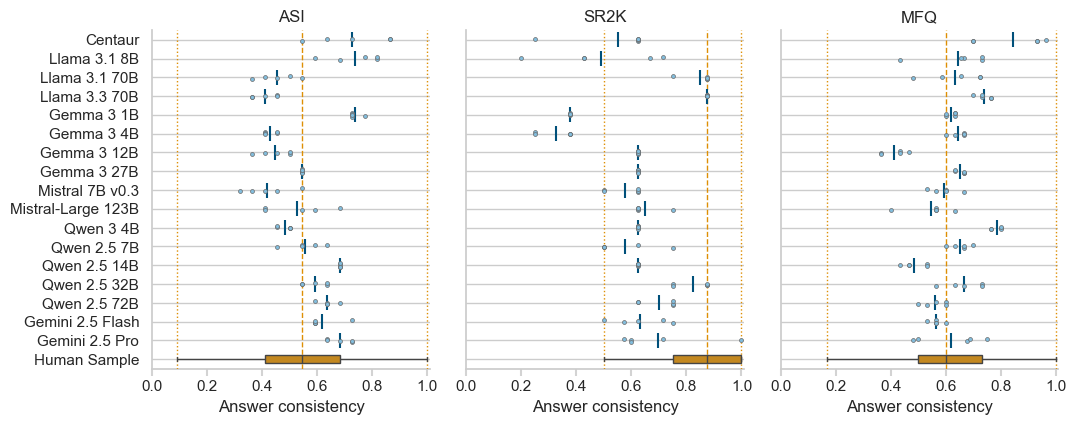

In [43]:
# Set a nice style
sns.set_theme(style="whitegrid")
sns.set_style({'axes.grid' : False})

model_df['model_display_name'] = model_df['model_name'].map(model_name_map)

# 1. Initialize the figure using ONLY the model data, showing individual seed points (strip)
g = sns.catplot(
    data=model_df,
    x='match_fraction',
    y='model_display_name',  # Use the new custom-named column
    col='test',
    kind='strip',
    order=custom_display_order, # Use the custom display order
    col_order=test_order,
    height=4.5, 
    aspect=0.8, 
    color="#82bddd",
    s=8,
    linewidth=0.5,
    jitter=True,
    zorder=10
)

# 2. Loop over facets to add boxplot
for i, ax in enumerate(g.axes.flat):
    test_name = g.col_names[i]

    sns.boxplot(
        data=model_df[model_df['test'] == test_name],
        x='match_fraction',
        y='model_display_name',  # Use the new custom-named column
        ax=ax,
        linewidth=1,
        showfliers=False,
        showbox=False,
        showcaps=False,
        medianprops={'visible': False},
        whiskerprops={'visible': False},
        #order=custom_display_order, # Use the custom display order
        zorder=5,
        
        # --- ADD MEAN LINE PROPERTIES HERE ---
        showmeans=True,
        meanline=True,
        
        meanprops={
            'color': "#00507a",
            'linestyle': '-',
            'linewidth': 1.5,
            'zorder': 7,
        }
    )
    
    
    
    # 2b. Add Human Sample boxplot and fix the axis if the test is relevant
    human_test_data = human_df[human_df['test'] == test_name]
    
    if not human_test_data.empty:
        # Draw the boxplot for the human data
        sns.boxplot(
            data=human_test_data,
            x='match_fraction',
            y = 'model_name', # model_name is here just "Human Sample"
            ax=ax,
            color="#de8f05",
            linewidth=1,
            width=0.4, 
            orient='h',
            showfliers=False,
            zorder=5 
        )

        # --- CALCULATE AND ADD VERTICAL LINES FOR HUMAN SAMPLE ---
        
        # 1. Calculate statistics
        scores = human_test_data['match_fraction']
        
        # Get Quartiles (Q1, Median/Q2, Q3)
        q1, median, q3 = np.percentile(scores, [25, 50, 75])
        iqr = q3 - q1
        
        # Whisker Fences (Inner fences: Q1 - 1.5*IQR, Q3 + 1.5*IQR)
        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr
        
        # Whisker Ends (The most extreme data point within the fences)
        whisker_low = scores[scores >= lower_fence].min()
        whisker_high = scores[scores <= upper_fence].max()
        
        # 2. Add Vertical Lines (ax.axvline)
        
        # Line for the Mean (Dashed)
        ax.axvline(
            x=median, 
            color="#de8f05",
            linestyle='--', 
            linewidth=1.0, 
            zorder=3,
            label='Human Mean'
        )
        
        # Lines for the Whisker Ends (Dotted)
        # Lower Whisker
        ax.axvline(
            x=whisker_low, 
            color="#de8f05", 
            linestyle=':', 
            linewidth=1.0, 
            zorder=3,
            label='Human Whisker' if i == 0 else None # Label only once for the legend
        )
        # Upper Whisker
        ax.axvline(
            x=whisker_high, 
            color="#de8f05", 
            linestyle=':', 
            linewidth=1.0, 
            zorder=3
        )
        

    # --- ADD MINOR TICKS TO X-AXIS ---
    
    # 1. Define the Minor Tick Locator
    # This sets minor ticks every 0.05 units (e.g., 0.05, 0.10, 0.15, ...)
    minor_locator = MultipleLocator(0.05)
    ax.xaxis.set_minor_locator(minor_locator)
    
    # 2. Customize the appearance of the minor ticks
    # We turn on the minor ticks but ensure no minor grid lines are drawn,
    # and set the color to grey.
    ax.tick_params(
        which='major',       # Apply to minor ticks
        axis='x',            # Apply only to x-axis
        length=5,            # Length of the tick mark
        width=1.5,           # Thickness of the tick mark
        color='lightgrey',   # Color of the tick mark
        #direction='in',      # Draw ticks inside the plot area
        bottom=True,         # Show ticks on the bottom axis
        top=False,           # Hide ticks on the top axis
    )
    ax.grid(axis='y')

# Set common labels and title
# g.set_axis_labels("Fraction of 'match' = True (per Seed/Case)", "Model/Sample")
g.set_titles("{col_name}")
#g.fig.suptitle('Model and Human Sample Match Fraction by Test', y=1.02)

# Ensure the x-axis scale is consistent and appropriate for fractions (0 to 1)
g.set(xlim=(0.0, 1.01))

g.set_axis_labels("Answer consistency", "")

# Tight layout for better spacing
plt.tight_layout(rect=[0, 0, 1, 0.98]) 

filename = "rel_af.svg"
plt.savefig(os.path.join(os.path.join(results_dir, filename)), bbox_inches="tight", format="svg")

# Display the plot
plt.show() # Omitted as per guidelines
plt.close()

In [44]:
mean_std_by_model_test = (
    model_df
    .groupby(['model_name', 'test'])['match_fraction']
    .agg(['mean', 'std'])
    .reset_index()
)

mean_std_by_model_test

,model_name,test,mean,std
0,Llama-3.1-70B-Instruct,ASI,0.454545,0.071870
1,Llama-3.1-70B-Instruct,MFQ,0.634483,0.102292
2,Llama-3.1-70B-Instruct,SR2K,0.850000,0.055902
3,Llama-3.1-8B-Instruct,ASI,0.736364,0.098543
4,Llama-3.1-8B-Instruct,MFQ,0.644368,0.123470
5,Llama-3.1-8B-Instruct,SR2K,0.487619,0.208047
6,Llama-3.1-Centaur-70B,ASI,0.727273,0.140100
7,Llama-3.1-Centaur-70B,MFQ,0.846667,0.134578
8,Llama-3.1-Centaur-70B,SR2K,0.550000,0.167705
9,Llama-3.3-70B-Instruct,ASI,0.409091,0.045455


# Reversed

In [45]:
df_re = df[df["version"].isin(["reversed", "og"])]

In [46]:
pivot_df_re = df_re.pivot_table(
    index=['item_id', 'model_name', 'seed', 'test'],
    columns='version',
    values='answer_reversed'
).reset_index()


# get matches
def check_match(row):
    og_val, af_val = row["og"], row["reversed"]
    if pd.isna(og_val) and pd.isna(af_val):
        return True           # both missing
    else:
        return og_val == af_val 
#pivot_df
pivot_df_re['match'] = pivot_df_re.apply(check_match, axis=1)


In [47]:
match_fraction_df_re = pivot_df_re.groupby(['model_name', 'test', 'seed'])['match'].mean().reset_index()
match_fraction_df_re = match_fraction_df_re.rename(columns={'match': 'match_fraction'})

model_df = match_fraction_df_re.copy()

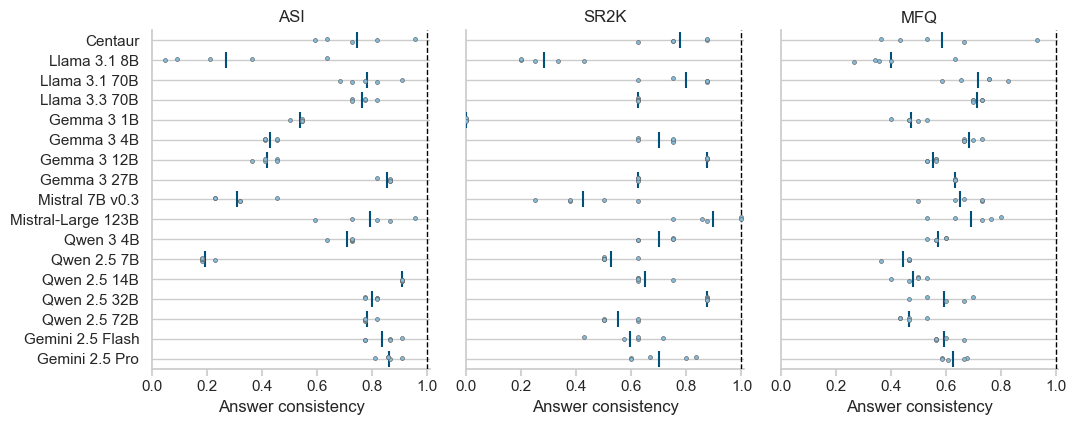

In [48]:
# Set a nice style
sns.set_theme(style="whitegrid")
sns.set_style({'axes.grid' : False})

model_df['model_display_name'] = model_df['model_name'].map(model_name_map)

# 1. Initialize the figure using ONLY the model data, showing individual seed points (strip)
g = sns.catplot(
    data=model_df,
    x='match_fraction',
    y='model_display_name',  # Use the new custom-named column
    col='test',
    kind='strip',
    order=custom_display_order, # Use the custom display order
    col_order=test_order,
    height=4.5, 
    aspect=0.8, 
    color="#82bddd",
    s=8,
    linewidth=0.5,
    jitter=True,
    zorder=10
)

# 2. Loop over facets to add boxplot
for i, ax in enumerate(g.axes.flat):
    test_name = g.col_names[i]

    sns.boxplot(
        data=model_df[model_df['test'] == test_name],
        x='match_fraction',
        y='model_display_name',  # Use the new custom-named column
        ax=ax,
        linewidth=1,
        showfliers=False,
        showbox=False,
        showcaps=False,
        medianprops={'visible': False},
        whiskerprops={'visible': False},
        #order=custom_display_order, # Use the custom display order
        zorder=5,
        
        # --- ADD MEAN LINE PROPERTIES HERE ---
        showmeans=True,
        meanline=True,
        
        meanprops={
            'color': "#00507a",
            'linestyle': '-',
            'linewidth': 1.5,
            'zorder': 7,
        }
    )
    
    
    
    # Baseline
    ax.axvline(
        x=1, 
        color="black", 
        linestyle='--', 
        linewidth=1.0, 
        zorder=3
    )
        

    # --- ADD MINOR TICKS TO X-AXIS ---
    
    # 1. Define the Minor Tick Locator
    # This sets minor ticks every 0.05 units (e.g., 0.05, 0.10, 0.15, ...)
    minor_locator = MultipleLocator(0.05)
    ax.xaxis.set_minor_locator(minor_locator)
    
    # 2. Customize the appearance of the minor ticks
    # We turn on the minor ticks but ensure no minor grid lines are drawn,
    # and set the color to grey.
    ax.tick_params(
        which='major',       # Apply to minor ticks
        axis='x',            # Apply only to x-axis
        length=5,            # Length of the tick mark
        width=1.5,           # Thickness of the tick mark
        color='lightgrey',   # Color of the tick mark
        #direction='in',      # Draw ticks inside the plot area
        bottom=True,         # Show ticks on the bottom axis
        top=False,           # Hide ticks on the top axis
    )
    ax.grid(axis='y')

# Set common labels and title
# g.set_axis_labels("Fraction of 'match' = True (per Seed/Case)", "Model/Sample")
g.set_titles("{col_name}")
#g.fig.suptitle('Model and Human Sample Match Fraction by Test', y=1.02)

# Ensure the x-axis scale is consistent and appropriate for fractions (0 to 1)
g.set(xlim=(0.0, 1.01))

g.set_axis_labels("Answer consistency", "")

# Tight layout for better spacing
plt.tight_layout(rect=[0, 0, 1, 0.98]) 

filename = "rel_reversed.svg"
plt.savefig(os.path.join(os.path.join(results_dir, filename)), bbox_inches="tight", format="svg")

# Display the plot
plt.show() # Omitted as per guidelines
plt.close()

In [49]:
mean_by_model_test = model_df.groupby(['model_name', 'test'])['match_fraction'].mean().reset_index()

pivoted_results = mean_by_model_test.pivot(index='model_name', 
                                columns='test', 
                                values='match_fraction')

pivoted_results.to_json(os.path.join(results_dir, "rel_reversed.json"), orient="columns") 


# safe to latex table
pivoted_results[["ASI", "MFQ", "SR2K"]].to_latex(
    buf = os.path.join(results_dir, "rel_reversed.tex"),
    header = ["ASI", "MFQ", "SR2K"],
    na_rep = "",
    float_format = "%.2f",
    column_format = "lSSS",
    caption = "Answer consistency reversed order of answer options",
    label = "tab:rel-r",
    )

In [50]:
mean_std_by_model_test = (
    model_df
    .groupby(['model_name', 'test'])['match_fraction']
    .agg(['mean', 'std'])
    .reset_index()
)

mean_std_by_model_test

,model_name,test,mean,std
0,Llama-3.1-70B-Instruct,ASI,0.781818,0.087434
1,Llama-3.1-70B-Instruct,MFQ,0.717241,0.095686
2,Llama-3.1-70B-Instruct,SR2K,0.800000,0.111803
3,Llama-3.1-8B-Instruct,ASI,0.269378,0.239280
4,Llama-3.1-8B-Instruct,MFQ,0.400394,0.138836
5,Llama-3.1-8B-Instruct,SR2K,0.282381,0.098221
6,Llama-3.1-Centaur-70B,ASI,0.745455,0.145880
7,Llama-3.1-Centaur-70B,MFQ,0.586667,0.224351
8,Llama-3.1-Centaur-70B,SR2K,0.775000,0.104583
9,Llama-3.3-70B-Instruct,ASI,0.763636,0.038030


# Changes EOS

In [51]:
df_eos = df[df["version"].isin(["changed_eos", "og"])]

In [52]:
pivot_df_eos = df_eos.pivot_table(
    index=['item_id', 'model_name', 'seed', 'test'],
    columns='version',
    values='answer_reversed'
).reset_index()


# get matches
def check_match(row):
    og_val, af_val = row["og"], row["changed_eos"]
    if pd.isna(og_val) and pd.isna(af_val):
        return True           # both missing
    else:
        return og_val == af_val 
#pivot_df
pivot_df_eos['match'] = pivot_df_eos.apply(check_match, axis=1)

In [61]:
pivot_df_eos_gemini = pivot_df_eos[pivot_df_eos["model_name"] == "gemini-2.5-pro"]
pivot_df_eos_gemini[pivot_df_eos_gemini["match"] == False]

version,item_id,model_name,seed,test,changed_eos,og,match
441,2.0,gemini-2.5-pro,3,ASI,NaN,0.0,False
444,2.0,gemini-2.5-pro,4,ASI,1.0,0.0,False
447,2.0,gemini-2.5-pro,5,ASI,NaN,0.0,False
697,3.0,gemini-2.5-pro,4,SR2K,NaN,1.0,False
938,4.0,gemini-2.5-pro,2,ASI,0.0,NaN,False
...,...,...,...,...,...,...,...
4778,27.0,gemini-2.5-pro,5,MFQ,5.0,0.0,False
4859,28.0,gemini-2.5-pro,1,MFQ,0.0,1.0,False
5030,30.0,gemini-2.5-pro,2,MFQ,3.0,NaN,False
5031,30.0,gemini-2.5-pro,3,MFQ,NaN,3.0,False


In [54]:
match_fraction_df_eos = pivot_df_eos.groupby(['model_name', 'test', 'seed'])['match'].mean().reset_index()
match_fraction_df_eos = match_fraction_df_eos.rename(columns={'match': 'match_fraction'})

model_df = match_fraction_df_eos.copy()

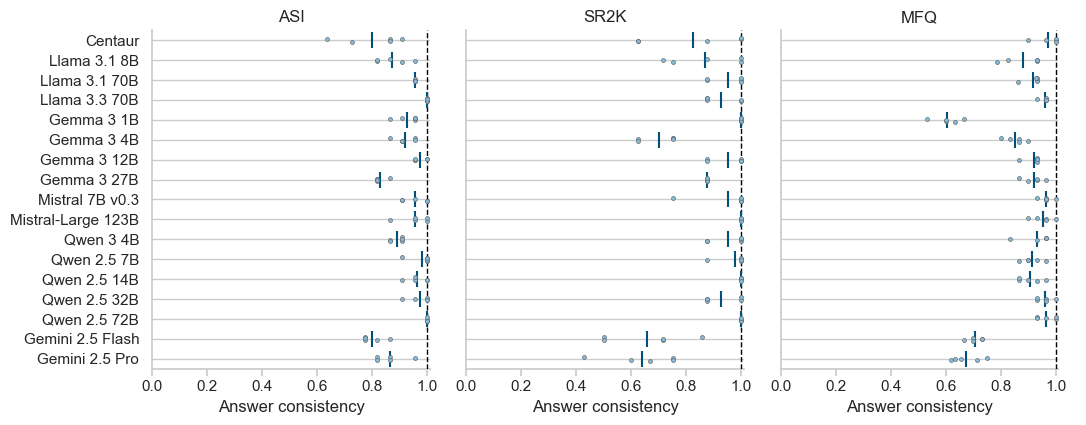

In [55]:
# Set a nice style
sns.set_theme(style="whitegrid")
sns.set_style({'axes.grid' : False})

model_df['model_display_name'] = model_df['model_name'].map(model_name_map)

# 1. Initialize the figure using ONLY the model data, showing individual seed points (strip)
g = sns.catplot(
    data=model_df,
    x='match_fraction',
    y='model_display_name',  # Use the new custom-named column
    col='test',
    kind='strip',
    order=custom_display_order, # Use the custom display order
    col_order=test_order,
    height=4.5, 
    aspect=0.8, 
    color="#82bddd",
    s=8,
    linewidth=0.5,
    jitter=True,
    zorder=10
)

# 2. Loop over facets to add boxplot
for i, ax in enumerate(g.axes.flat):
    test_name = g.col_names[i]

    sns.boxplot(
        data=model_df[model_df['test'] == test_name],
        x='match_fraction',
        y='model_display_name',  # Use the new custom-named column
        ax=ax,
        linewidth=1,
        showfliers=False,
        showbox=False,
        showcaps=False,
        medianprops={'visible': False},
        whiskerprops={'visible': False},
        #order=custom_display_order, # Use the custom display order
        zorder=5,
        
        # --- ADD MEAN LINE PROPERTIES HERE ---
        showmeans=True,
        meanline=True,
        
        meanprops={
            'color': "#00507a",
            'linestyle': '-',
            'linewidth': 1.5,
            'zorder': 7,
        }
    )
    
    
    
    # Baseline
    ax.axvline(
        x=1, 
        color="black", 
        linestyle='--', 
        linewidth=1.0, 
        zorder=3
    )
        

    # --- ADD MINOR TICKS TO X-AXIS ---
    
    # 1. Define the Minor Tick Locator
    # This sets minor ticks every 0.05 units (e.g., 0.05, 0.10, 0.15, ...)
    minor_locator = MultipleLocator(0.05)
    ax.xaxis.set_minor_locator(minor_locator)
    
    # 2. Customize the appearance of the minor ticks
    # We turn on the minor ticks but ensure no minor grid lines are drawn,
    # and set the color to grey.
    ax.tick_params(
        which='major',       # Apply to minor ticks
        axis='x',            # Apply only to x-axis
        length=5,            # Length of the tick mark
        width=1.5,           # Thickness of the tick mark
        color='lightgrey',   # Color of the tick mark
        #direction='in',      # Draw ticks inside the plot area
        bottom=True,         # Show ticks on the bottom axis
        top=False,           # Hide ticks on the top axis
    )
    ax.grid(axis='y')

# Set common labels and title
# g.set_axis_labels("Fraction of 'match' = True (per Seed/Case)", "Model/Sample")
g.set_titles("{col_name}")
#g.fig.suptitle('Model and Human Sample Match Fraction by Test', y=1.02)

# Ensure the x-axis scale is consistent and appropriate for fractions (0 to 1)
g.set(xlim=(0.0, 1.01))

g.set_axis_labels("Answer consistency", "")

# Tight layout for better spacing
plt.tight_layout(rect=[0, 0, 1, 0.98]) 

filename = "rel_changed_eos.svg"
plt.savefig(os.path.join(os.path.join(results_dir, filename)), bbox_inches="tight", format="svg")

# Display the plot
plt.show() # Omitted as per guidelines
plt.close()

In [56]:
model_df

,model_name,test,seed,match_fraction,model_display_name
0,Llama-3.1-70B-Instruct,ASI,1,0.954545,Llama 3.1 70B
1,Llama-3.1-70B-Instruct,ASI,2,0.954545,Llama 3.1 70B
2,Llama-3.1-70B-Instruct,ASI,3,0.954545,Llama 3.1 70B
3,Llama-3.1-70B-Instruct,ASI,4,0.954545,Llama 3.1 70B
4,Llama-3.1-70B-Instruct,ASI,5,0.954545,Llama 3.1 70B
...,...,...,...,...,...
250,gemma-3-4b-it,SR2K,1,0.750000,Gemma 3 4B
251,gemma-3-4b-it,SR2K,2,0.625000,Gemma 3 4B
252,gemma-3-4b-it,SR2K,3,0.625000,Gemma 3 4B
253,gemma-3-4b-it,SR2K,4,0.750000,Gemma 3 4B


In [57]:
mean_by_model_test = model_df.groupby(['model_name', 'test'])['match_fraction'].mean().reset_index()

pivoted_results = mean_by_model_test.pivot(index='model_name', 
                                columns='test', 
                                values='match_fraction')

pivoted_results.to_json(os.path.join(results_dir, "rel_changed_eos.json"), orient="columns") 


# safe to latex table
pivoted_results[["ASI", "MFQ", "SR2K"]].to_latex(
    buf = os.path.join(results_dir, "rel_changed_eos.tex"),
    header = ["ASI", "MFQ", "SR2K"],
    na_rep = "",
    float_format = "%.2f",
    column_format = "lSSS",
    caption = "Answer consistency changed end-of-sentence",
    label = "tab:rel-eos",
    )

In [58]:
mean_std_by_model_test = (
    model_df
    .groupby(['model_name', 'test'])['match_fraction']
    .agg(['mean', 'std'])
    .reset_index()
)

mean_std_by_model_test

,model_name,test,mean,std
0,Llama-3.1-70B-Instruct,ASI,0.954545,0.000000
1,Llama-3.1-70B-Instruct,MFQ,0.916749,0.030586
2,Llama-3.1-70B-Instruct,SR2K,0.950000,0.068465
3,Llama-3.1-8B-Instruct,ASI,0.872727,0.059265
4,Llama-3.1-8B-Instruct,MFQ,0.882660,0.070949
5,Llama-3.1-8B-Instruct,SR2K,0.867857,0.134582
6,Llama-3.1-Centaur-70B,ASI,0.800000,0.114090
7,Llama-3.1-Centaur-70B,MFQ,0.973333,0.043461
8,Llama-3.1-Centaur-70B,SR2K,0.825000,0.189572
9,Llama-3.3-70B-Instruct,ASI,1.000000,0.000000
